In [3]:
# We are going to create and train a self_supervised PatchTST model, and then fine-tune it using supervised learning.
# The model is based on the paper "Self-Supervised Learning of Patch Transformers for Time Series Classification" by Xu et al. (2022).

# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader, Subset

import random
import os
import numpy as np
import pandas as pd
import math
import sys
from collections import Counter
from itertools import chain
from typing import List
import textwrap

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from google.colab import drive

random.seed(0)
torch.manual_seed(0)
drive.mount('/content/gdrive')

base_dir = "/content/gdrive/MyDrive/CS4782-Final/"
sys.path.append(base_dir)
%load_ext autoreload
%autoreload 1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(F"Device set to {device}")

from PatchTST_self_supervised import PatchTSTSelfSupervised, self_supervised_loss
from PatchTST import PatchTST
from utils import train, val, train_self_supervised, val_self_supervised

from data_loader import TimeSeriesDataset, SelfSupervisedTimeSeriesDataset
from sklearn.preprocessing import StandardScaler

Mounted at /content/gdrive
Device set to cuda


In [ ]:
criterion = nn.MSELoss()
input_length    = 336   # e.g. past 336 steps
batch_size      = 32

df   = pd.read_csv(base_dir + "data/ETTh1.csv", parse_dates=["date"])
vars = ['HUFL','HULL','MUFL','MULL','LUFL','LULL','OT']
data = df[vars].values

# 2) Determine time‐based split point
n_train_time = int(0.8 * len(data))

# 3) Slice train & val (include overlap of input_length for first val window)
train_raw = data[:n_train_time]
val_raw   = data[n_train_time - input_length :]

# 4) Fit scaler on TRAIN ONLY, then transform both
scaler     = StandardScaler().fit(train_raw)
train_data = scaler.transform(train_raw)
val_data   = scaler.transform(val_raw)

# 5) Build datasets & loaders
selfsup_train_ds = SelfSupervisedTimeSeriesDataset(train_data, input_length)
selfsup_val_ds   = SelfSupervisedTimeSeriesDataset(val_data, input_length)

selfsup_train_loader = DataLoader(selfsup_train_ds, batch_size=32, shuffle=True, drop_last=True)
selfsup_val_loader   = DataLoader(selfsup_val_ds, batch_size=32, shuffle=False)

df   = pd.read_csv(base_dir + "data/ETTh1.csv", parse_dates=["date"])
vars = ['HUFL','HULL','MUFL','MULL','LUFL','LULL','OT']
data = df[vars].values

# 2) Determine time‐based split point
n_train_time = int(0.8 * len(data))

# 3) Slice train & val (include overlap of input_length for first val window)
train_raw = data[:n_train_time]
val_raw   = data[n_train_time - input_length :]

# 4) Fit scaler on TRAIN ONLY, then transform both
scaler     = StandardScaler().fit(train_raw)
train_data = scaler.transform(train_raw)
val_data   = scaler.transform(val_raw)

# 5) Array‐based dataset
class ArrayTimeSeriesDataset(Dataset):
    def __init__(self, data: np.ndarray, input_length: int, horizon: int):
        """
        data: 2D array [T, n_vars] already scaled
        """
        self.data = data
        self.L, self.h = input_length, horizon
        self.n_samples = len(data) - input_length - horizon + 1

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.L]                       # [L, n_vars]
        y = self.data[idx + self.L : idx + self.L + self.h]     # [h, n_vars]
        # transpose to [n_vars, seq_len]
        return (
            torch.from_numpy(x.T).float(),
            torch.from_numpy(y.T).float()
        )


patch_lengths = [2, 4, 8, 12, 16, 24, 32, 40]

end_val_loss = []

for length in patch_lengths:
    print(f"Patch Length: {length}")
    print("-" * 20)

    supervised_model = PatchTST(
        input_length=input_length,
        patch_len=length,
        stride=length,
        n_heads=4,
        d_model=16,
        forecast_horizon=96
    ).to(device)
    optimizer = optim.Adam(supervised_model.parameters(), lr=1e-3, betas=(0.9, 0.98), eps=1e-9)

    train_ds = ArrayTimeSeriesDataset(train_data, input_length, 96)
    val_ds   = ArrayTimeSeriesDataset(val_data,   input_length, 96)

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  drop_last=True)
    val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, drop_last=False)

    fine_tune_train_loss_arr, _, fine_tune_val_loss_arr, _ = train(
        supervised_model, train_loader, val_loader,
        criterion=criterion, epochs=10,
        optimizer=optimizer, device=device
    )
    end_val_loss.append(fine_tune_val_loss_arr[-1])


Patch Length: 2
--------------------
Starting training...
Epoch 1/10


train: 100%|██████████| 422/422 [00:46<00:00,  9.06it/s]


Epoch 1: Train Loss = 0.4319, Train MAE = 0.4554 | Val   Loss = 0.4512, Val   MAE = 0.4635
Epoch 2/10


train: 100%|██████████| 422/422 [00:46<00:00,  9.01it/s]


Epoch 2: Train Loss = 0.3852, Train MAE = 0.4285 | Val   Loss = 0.4286, Val   MAE = 0.4511
Epoch 3/10


...

Epoch 8: Train Loss = 0.3937, Train MAE = 0.4388 | Val   Loss = 0.4518, Val   MAE = 0.4740
Epoch 9/10


train: 100%|██████████| 422/422 [00:03<00:00, 109.02it/s]


Epoch 9: Train Loss = 0.3922, Train MAE = 0.4381 | Val   Loss = 0.4464, Val   MAE = 0.4693
Epoch 10/10


train: 100%|██████████| 422/422 [00:04<00:00, 97.75it/s]


Epoch 10: Train Loss = 0.3894, Train MAE = 0.4373 | Val   Loss = 0.4465, Val   MAE = 0.4685
Training finished.


In [ ]:
print(list(zip(patch_lengths, end_val_loss)))

[(2, 0.42220552223470975), (4, 0.42941089213456746), (8, 0.4322637703340009), (12, 0.43083215603288616), (16, 0.4346804698964335), (24, 0.4322896395932953), (32, 0.44403429512145387), (40, 0.44650874427467024)]


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

patch_lengths = [2, 4, 8, 12, 16, 24, 32, 40]
end_val_losses = [0.42220552223470975, 0.42941089213456746, 0.4322637703340009, 0.43083215603288616, 0.4346804698964335, 0.4322896395932953, 0.44403429512145387, 0.44650874427467024]

# Try to use a Proxima Nova–like font (fallback to DejaVu or Arial if not available)
# You can register Proxima Nova if you have the .ttf file locally
try:
    font_path = "/content/gdrive/MyDrive/CS4782-Final/proximanova_regular.ttf"  # update with your actual path
    bold_path = "/content/gdrive/MyDrive/CS4782-Final/proximanova_bold.otf"
    bold = fm.FontProperties(fname=bold_path)
    prop = fm.FontProperties(fname=font_path)
except:
    prop = fm.FontProperties(family="DejaVu Sans")  # closest built-in fallback
    bold = fm.FontProperties(fname="DejaVu Sans")

color = "#3c85c7"
# Plot
plt.figure(figsize=(8, 5))
plt.plot(patch_lengths, end_val_losses, marker='o', color='#3c85c7', linewidth=2)

plt.title("Patch Length", fontproperties=bold, fontsize=20, color=color)
plt.xlabel("Patch Length", fontproperties=prop, fontsize=14, color=color)
plt.ylabel("MSE", fontproperties=prop, fontsize=14, color=color)
plt.xticks(fontproperties=prop)
plt.yticks(fontproperties=prop)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


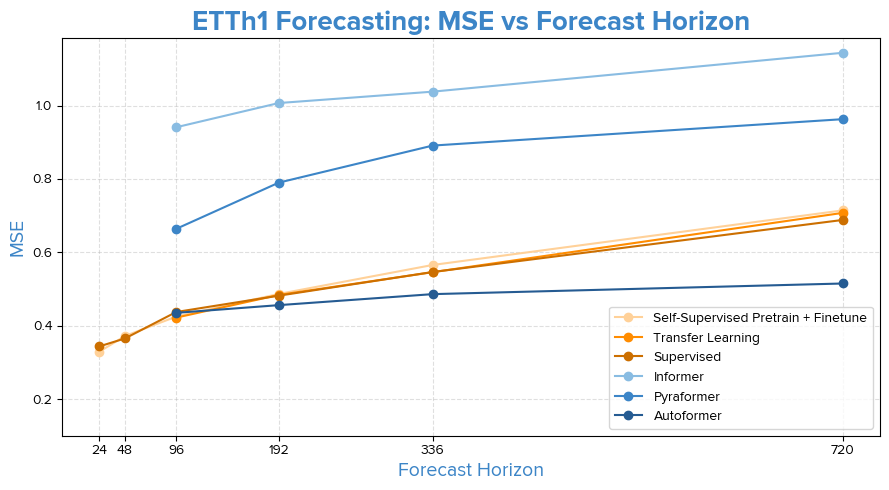

In [8]:
horizons = [24, 48, 96, 192, 336, 720]
mse_supervised = [0.3435, 0.3652, 0.4373, 0.4818, 0.5463, 0.6883]
mse_selfsup = [0.3289491703067351, 0.3718768596925117, 0.4247183399099224,
               0.4865285615319187, 0.5654917169700969, 0.7143809271269831]
mse_sup_42 = [0.37278141901580564, 0.40083555766829737, 0.4492974140734043, 0.520216232509289, 0.5842955883103188, 0.7864659209361021]
mse_informer = [None,None, 0.941, 1.007, 1.038, 1.144]
mse_pyraformer = [None,None, 0.664, 0.790, 0.891, 0.963]
mse_autoformer = [None,None, 0.435, 0.456, 0.486, 0.515]
mse_transfer = [None, None, 0.42197386330028754, 0.4838254153728485, 0.5458687354217876, 0.7075871201767319]

# Try to use Proxima Nova–like font if available
try:
    font_path = "/content/gdrive/MyDrive/CS4782-Final/proximanova_regular.ttf"  # update with your actual path
    bold_path = "/content/gdrive/MyDrive/CS4782-Final/proximanova_bold.otf"
    bold = fm.FontProperties(fname=bold_path)
    prop = fm.FontProperties(fname=font_path)
except:
    prop = fm.FontProperties(family="DejaVu Sans")  # closest built-in fallback
    bold = fm.FontProperties(fname="DejaVu Sans")

# Gradient blues for each line
colors = {
    "Supervised": "#CC6F00",
    "Self-Supervised Pretrain + Finetune": "#FFD199",
    "Informer": "#89bce2",
    "Pyraformer": "#3c85c7",
    "Autoformer": "#255b92",
    "Transfer": "#FF8C00"
}

# Plot
plt.figure(figsize=(9, 5))

plt.plot(horizons, mse_selfsup, marker='o', label='Self-Supervised Pretrain + Finetune', color=colors["Self-Supervised Pretrain + Finetune"])
plt.plot(horizons, mse_transfer, marker='o', label='Transfer Learning', color=colors["Transfer"])
plt.plot(horizons, mse_supervised, marker='o', label='Supervised', color=colors["Supervised"])

# plt.plot(horizons, mse_sup_42, marker='o', label='PatchTST/42', color=colors["PatchTST/42"])
plt.plot(horizons, mse_informer, marker='o', label='Informer', color=colors["Informer"])
plt.plot(horizons, mse_pyraformer, marker='o', label='Pyraformer', color=colors["Pyraformer"])
plt.plot(horizons, mse_autoformer, marker='o', label='Autoformer', color=colors["Autoformer"])


plt.xlabel('Forecast Horizon', fontproperties=prop, fontsize=14, color=color)
plt.ylabel('MSE', fontproperties=prop, fontsize=14, color=color)
plt.title('ETTh1 Forecasting: MSE vs Forecast Horizon', fontproperties=bold, fontsize=20, color=color)
plt.legend(prop=prop)
plt.xticks(horizons, fontproperties=prop)
plt.yticks(fontproperties=prop)
plt.grid(True, linestyle='--', alpha=0.4)
plt.ylim(bottom=0.1)

plt.tight_layout()
plt.show()

In [13]:
horizons = [24, 48, 96, 192, 336, 720]
mse_supervised = [0.3435, 0.3652, 0.4373, 0.4818, 0.5463, 0.6883]
mse_selfsup = [0.3289491703067351, 0.3718768596925117, 0.4247183399099224,
               0.4865285615319187, 0.5654917169700969, 0.7143809271269831]
mse_sup_42 = [0.37278141901580564, 0.40083555766829737, 0.4492974140734043, 0.520216232509289, 0.5842955883103188, 0.7864659209361021]
mse_informer = [None,None, 0.941, 1.007, 1.038, 1.144]
mse_pyraformer = [None,None, 0.664, 0.790, 0.891, 0.963]
mse_autoformer = [None,None, 0.435, 0.456, 0.486, 0.515]
mse_transfer = [None, None, 0.42197386330028754, 0.4838254153728485, 0.5458687354217876, 0.7075871201767319]

mse_supervised[2]/mse_informer[2]

0.4647183846971308